# Deconvolution of Spatial Wavelet Coefficient Representation of Chromatin Images
February 15, 2024

A notebook to test the idea of whether we can deconvolve wavelet coefficients of the chromatin image data.


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
from cc_src.chromatin_model import ChromatinModel
from src.config import load_yl_replicate1_rg1_alpha_vst_config

gene_name = 'CLB2'
config1 = load_yl_replicate1_rg1_alpha_vst_config()
chromatin_model = ChromatinModel(config1)
chromatin_model.load_mnase_gene(gene_name, 1)

Loading MNase reads for CLB2...Done.


In [14]:
chromatin_model.create_deconvolution_bins(smoothing=False)

Unflattened the input data is of shape: (16, 16, 50)
The size of our input data, G is: (16, 800)


In [34]:
from src.chromatin_wavelets import ChromatinWavelets

chrom_wavelets = ChromatinWavelets(chromatin_model)

In [85]:
chrom_wavelets.create_coefficients()

Created coefficients matrix of shape: (16, 4, 12, 29)
Created coefficients vectorized matrix of shape: (16, 1392)


In [88]:
recon_coefficients_mat = chrom_wavelets.convert_vectorized_coeffs_to_mat(chrom_wavelets.coeffs_vec)

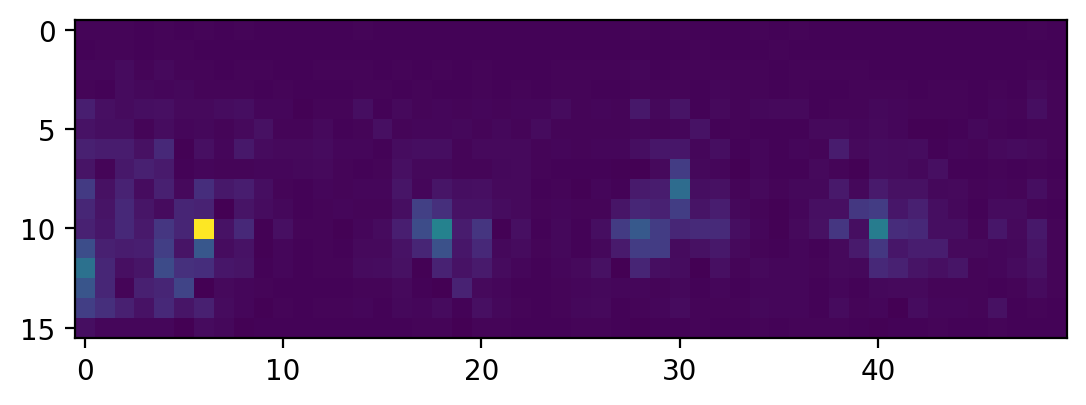

In [83]:
imgs = chrom_wavelets.reconstruct_images(recon_coefficients_mat)
plt.imshow(imgs[0])

In [89]:
# Now, can we deconvolve the coefficients vector?
chromatin_model.setup_deconv_model()
deconv_model = chromatin_model.deconv_model

In [90]:
G = chrom_wavelets.coeffs_vec

In [105]:

# Threshold G, such that there are non negative values
# This effectively compresses the coefficient matrix
# and removes negative values from G which would cause issues with the solver.
G = chrom_wavelets.coeffs_vec.copy()
G[G < 0] = 0


In [106]:
(G<0).sum()

0

(array([2.1278e+04, 6.5400e+02, 2.0600e+02, 7.8000e+01, 2.6000e+01,
        7.0000e+00, 9.0000e+00, 6.0000e+00, 7.0000e+00, 1.0000e+00]),
 array([ 0.        ,  5.42730628, 10.85461256, 16.28191885, 21.70922513,
        27.13653141, 32.56383769, 37.99114397, 43.41845026, 48.84575654,
        54.27306282]),
 <BarContainer object of 10 artists>)

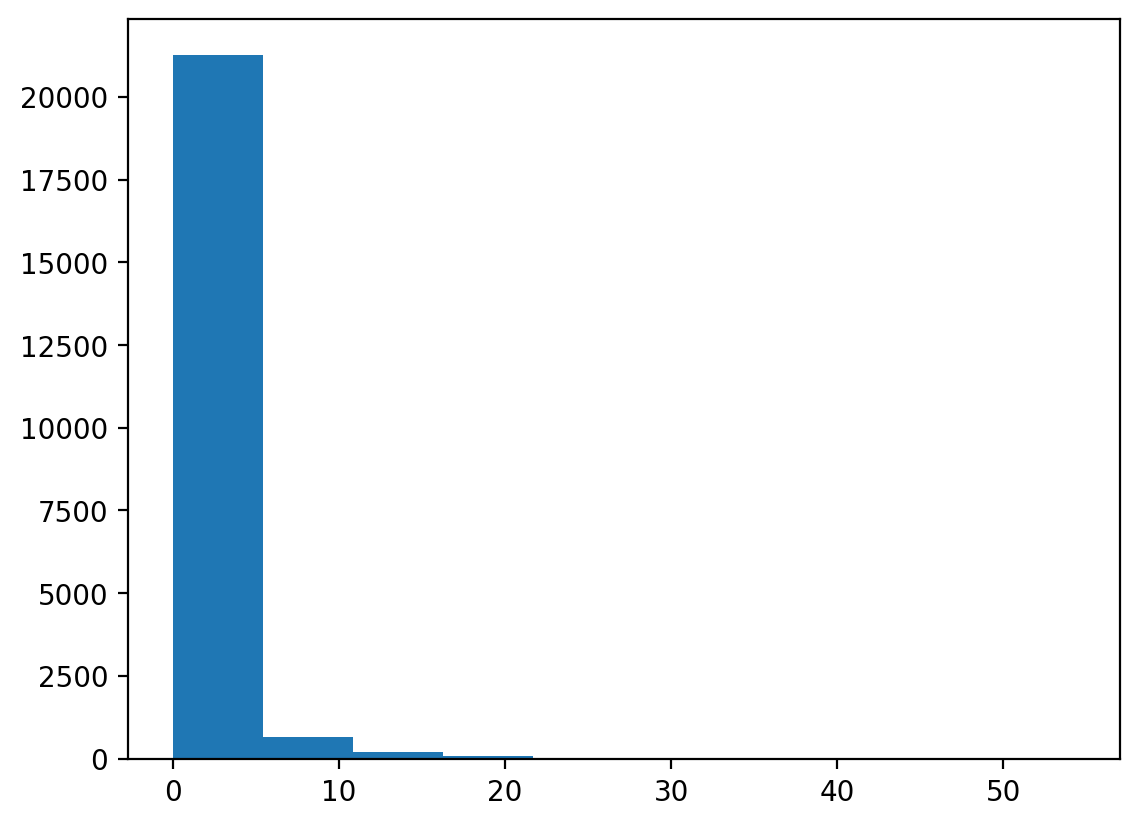

In [107]:
plt.hist(G.flatten())

In [ ]:
from src.deconvolve_chromatin import deconvolve_chromatin_H

G = chrom_wavelets.coeffs_vec
f, rn, sn = deconvolve_chromatin_H(deconv_model, deconv_model.H, G, verbose=True,
                                  allow_negative=True)


                                     CVXPY                                     
                                     v1.4.1                                    
(CVXPY) Feb 15 10:35:17 AM: Your problem has 315984 variables, 0 constraints, and 0 parameters.
(CVXPY) Feb 15 10:35:17 AM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Feb 15 10:35:17 AM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Feb 15 10:35:17 AM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Feb 15 10:35:17 AM: Your problem is compiled with the CPP canonicalization backend.
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
(CVXPY) Feb 15 10:35:17 AM: Compiling problem (target solver=MOSEK).